# Processing Inhibitor Data

____

In [14]:
from pathlib import Path
current_dir = Path().resolve()
from microlive.imports import *
from microlive import microscopy as mi
main_dir = Path().resolve().parent
one_drive_dir = mi.Utilities.get_one_drive_dir()
import inhibitors as INH

## Data Configuration
___

In [20]:
# Loading data
        #RMS External Drive Location:    'E:\Co-translational folding (CoF) paper\4xGFPq-2xmChq\sf_Har'
        #Ning Zhao OneDrive Location:    '...General - Zhao (NZ) Lab\Zhao lab shared folder\Our papers\co-translational folding paper\Fig 4\Fig 4_Harringtonine analysis_GFPFast'


# ── Data Path ─────────────────────────────────────────────
data_dir = one_drive_dir.joinpath('General - Zhao (NZ) Lab\Gui RMS Analyses\sf_Har')


# ── Processing Parameters ─────────────────────────────────
inhibitor_frame_index = 4  # 0-indexed: frame when treatment was applied
use_sem = True
show_summary = True
show_individual_trajectories = False
max_percentage_threshold_after_treatment = None
threshold_percentage_for_runoff = 0.5
use_sigmoidal_fit = True
# ── Plotting Parameters ───────────────────────────────────
figsize = (8, 4)
ylims = (0, 1.4)
xlims = (-5, 6)
results_folder = None  # Set to a Path to save plots


In [25]:
data_dir

#C:\Users\searsrh\OneDrive - The University of Colorado Denver\General - Zhao (NZ) Lab\Gui RMS Analyses\sf_Har

WindowsPath('C:/Users/searsrh/OneDrive - The University of Colorado Denver/General - Zhao (NZ) Lab/Gui RMS Analyses/sf_Har')

## HA Channel (pRS027)
___

No data to plot.


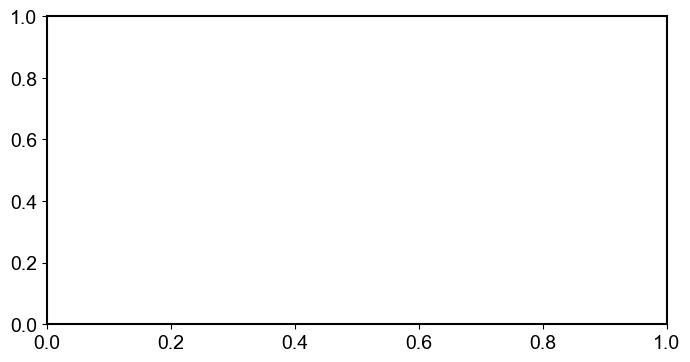

In [22]:
substring_in_data_dir = 'pRS027'
selected_field = 'spot_int_ch_1'
plot_name = 'pRS027_HA'

responding_indices_pRS027_HA, frames_pRS027_HA, intensities_pRS027_HA, _, _, _, _ = INH.process_inhibitor_data(
    data_dir, inhibitor_frame_index, substring_in_data_dir, selected_field,
    use_sem, show_summary, max_percentage_threshold_after_treatment,
)

INH.plot_inhibitor(
    frames_pRS027_HA, intensities_pRS027_HA, inhibitor_frame_index,
    show_runoff_time=True,
    plot_name=plot_name,
    threshold_percentage_for_runoff=threshold_percentage_for_runoff,
    figsize=figsize,
    ylims=ylims,
)


In [23]:
responding_indices_pRS027_HA

## GFP Channel (pRS027)
___

No data to plot.


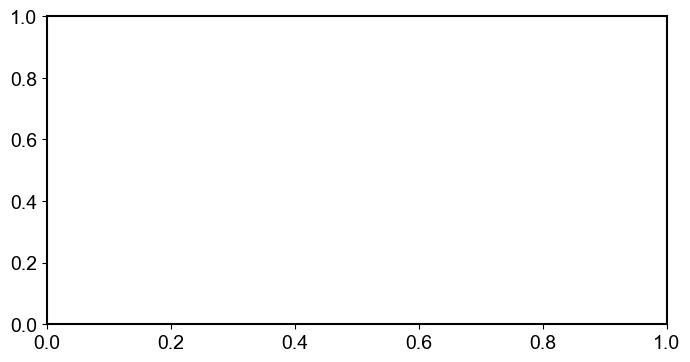

In [17]:
substring_in_data_dir = 'pRS027'
selected_field = 'spot_int_ch_0'
plot_name = 'pRS027_GFP'

responding_indices_pRS027_GFP, frames_pRS027_GFP, intensities_pRS027_GFP, _, _, _, _ = INH.process_inhibitor_data(
    data_dir, inhibitor_frame_index, substring_in_data_dir, selected_field,
    use_sem, show_summary, max_percentage_threshold_after_treatment,
)

INH.plot_inhibitor(
    frames_pRS027_GFP, intensities_pRS027_GFP, inhibitor_frame_index,
    show_runoff_time=True,
    plot_name=plot_name,
    threshold_percentage_for_runoff=threshold_percentage_for_runoff,
    figsize=figsize,
    ylims=ylims,
)


## Multi-Channel Comparison
___

TypeError: 'NoneType' object is not subscriptable

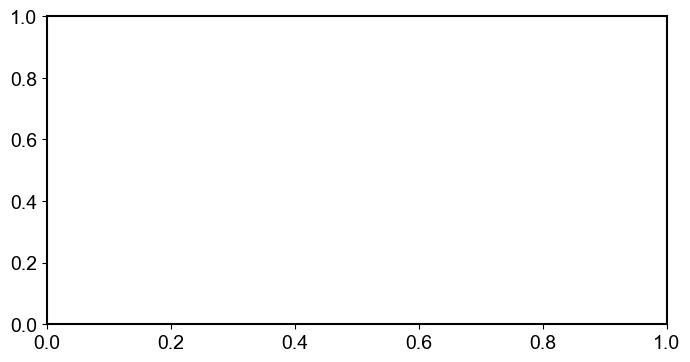

In [18]:
INH.plot_multiple_inhibitors(
    [frames_pRS027_HA, frames_pRS027_GFP],
    [intensities_pRS027_HA, intensities_pRS027_GFP],
    inhibitor_frame_index,
    responding_indices_list=[responding_indices_pRS027_HA, responding_indices_pRS027_GFP],
    colors=['magenta', 'green'],
    legend_labels=['pRS027_HA', 'pRS027_GFP'],
    plot_name='HT_multi',
    threshold_percentage_for_runoff=-0.4,
    ylims = (0, 1.4),
    use_sigmoidal_fit=use_sigmoidal_fit,
    figsize=figsize,
    use_sem=use_sem,
    show_individual_trajectories=show_individual_trajectories,
)
